   group  count
0      0  12470
1      1  11967
2      2  10459
3      3  11487
4      4   9745
5      5  11087
6      6  10434
7      7  11329
8      8  10535
9      9  10751
单个 post 的最大关联结果数量: 384
单个 post 的最小关联结果数量: 1
单个 post 的平均关联结果数量: 4.928


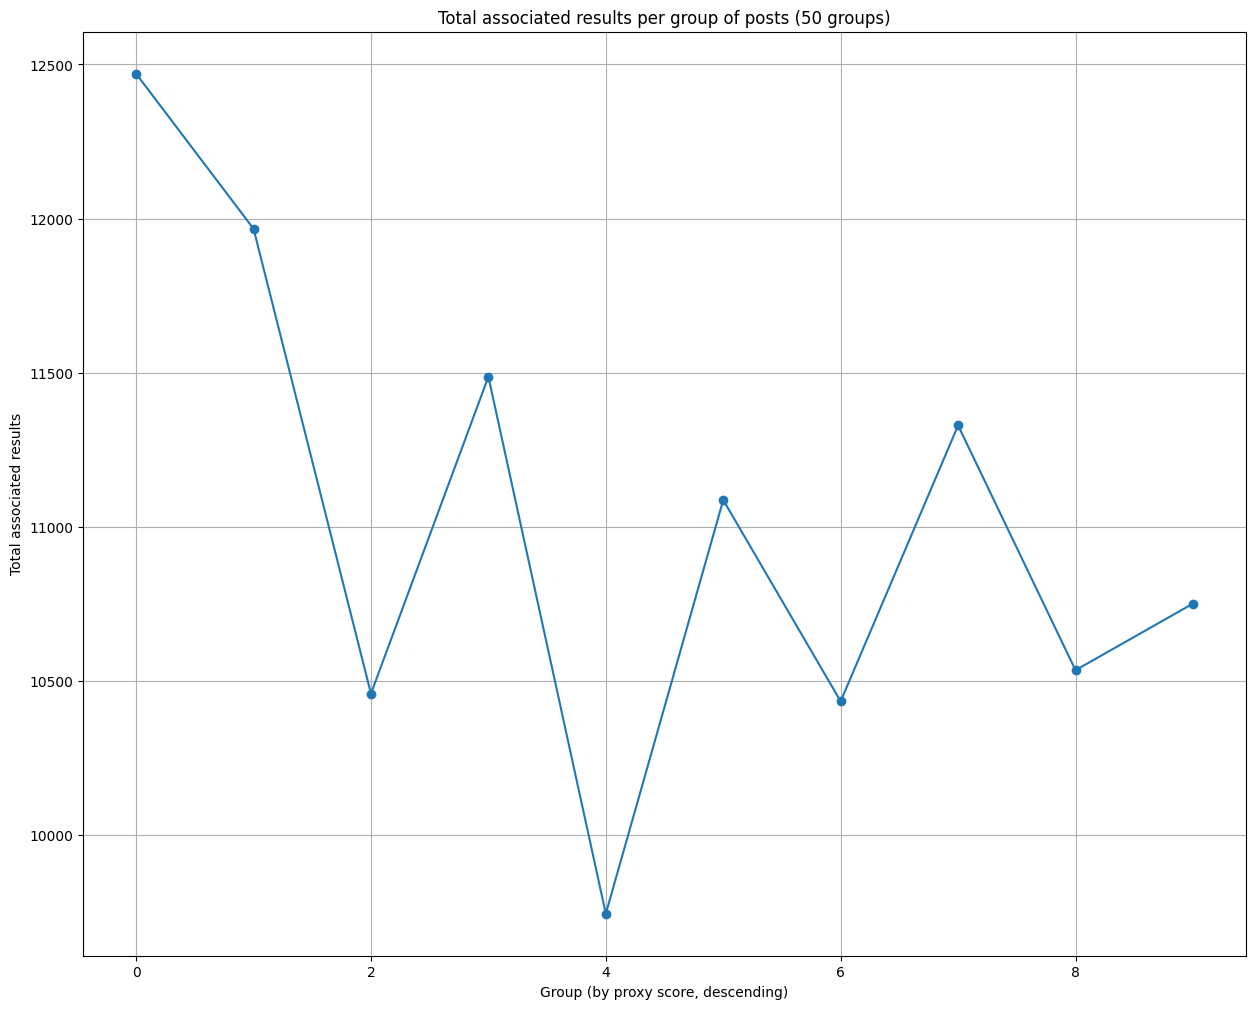

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取子图匹配结果文件
df = pd.read_csv("/home/wangshuo/projects/Neo4j_Exp/pythonProject/output/query_results.csv")

# 按 postId 分组，统计每个 post 的关联结果数量，并取 proxy 值
posts = df.groupby("postId").agg(
    count=("commentId", "count"),
    proxy=("post_proxy4b1", "first")
).reset_index()

# 按 proxy 降序排序
posts = posts.sort_values(by="proxy", ascending=False).reset_index(drop=True)

# 分成 50 份
posts["group"] = pd.qcut(posts.index, 10, labels=False, duplicates="drop")

# 每组的关联结果总数
group_stats = posts.groupby("group")["count"].sum().reset_index()

# 打印结果
print(group_stats)
max_post = posts["count"].max()
min_post = posts["count"].min()
mean_post = posts["count"].mean()

print("单个 post 的最大关联结果数量:", max_post)
print("单个 post 的最小关联结果数量:", min_post)
print("单个 post 的平均关联结果数量:", mean_post)

# 绘制折线图
plt.figure(figsize=(15, 12))
plt.plot(group_stats["group"], group_stats["count"], marker="o")
plt.xlabel("Group (by proxy score, descending)")
plt.ylabel("Total associated results")
plt.title("Total associated results per group of posts (50 groups)")
plt.grid(True)
plt.show()


统计结果：
w: 平均 4.9280, 最大 384.0, 最小 1.0, 方差 116.6866
a: 平均 12.9835, 最大 4677.0, 最小 0.0, 方差 3989.0185


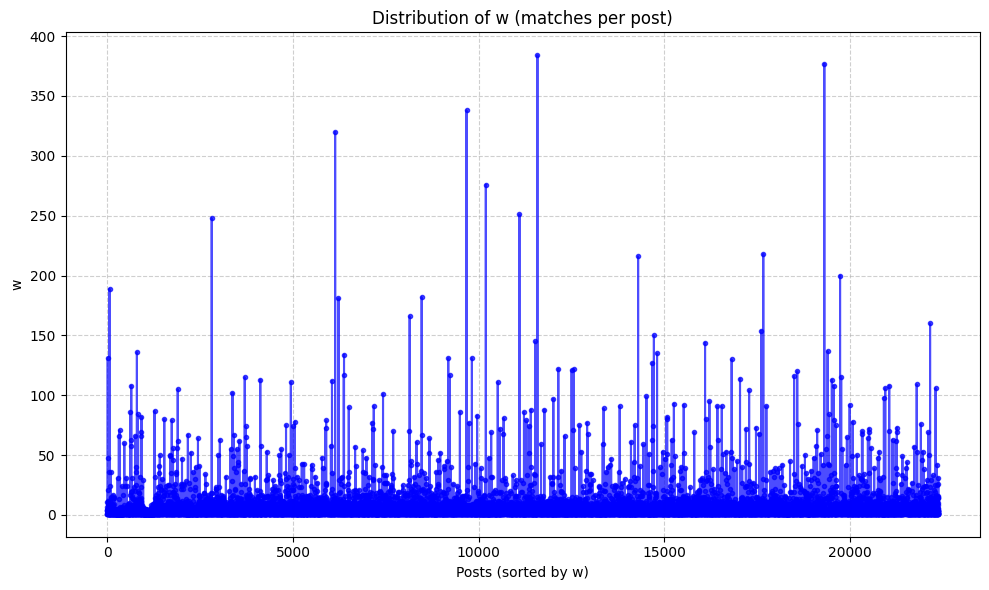

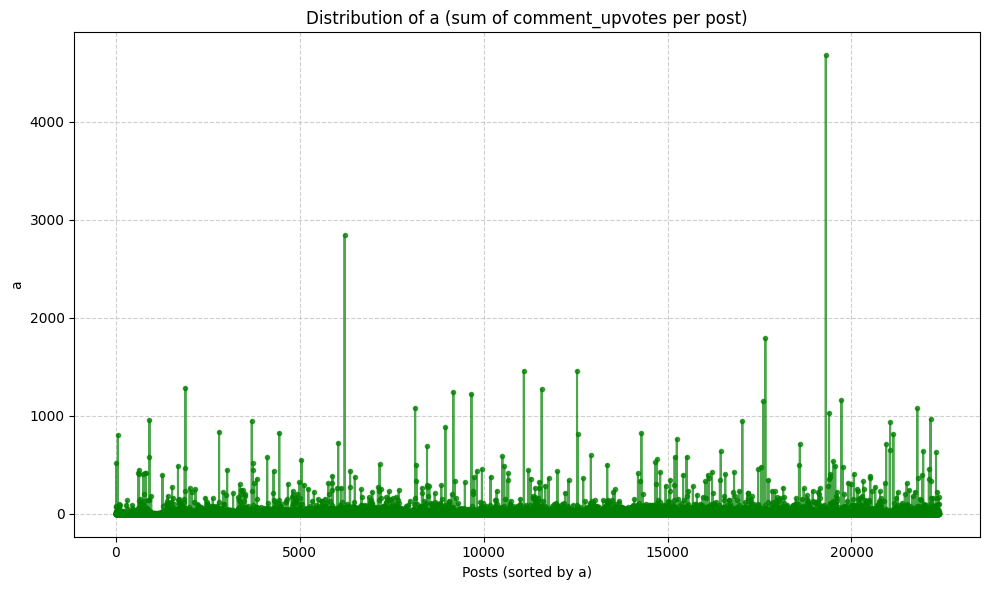

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_w_a_distribution(csv_path: str):
    # 读取数据
    df = pd.read_csv(csv_path)

    # ---- 按 post 聚合 ----
    df["comment_upvotes"] = pd.to_numeric(df["comment_upvotes"], errors="coerce").fillna(0).astype(float)
    g = df.groupby("postId", sort=False)
    posts = pd.DataFrame({
        "postId": list(g.groups.keys()),
        "w": g.size().values.astype(float),                   # 每个 post 的子图匹配数量
        "a": g["comment_upvotes"].sum().values.astype(float)  # 每个 post 的总 upvotes
    })

    # ---- 打印统计 ----
    print("统计结果：")
    print(f"w: 平均 {posts['w'].mean():.4f}, 最大 {posts['w'].max()}, 最小 {posts['w'].min()}, 方差 {posts['w'].var(ddof=1):.4f}")
    print(f"a: 平均 {posts['a'].mean():.4f}, 最大 {posts['a'].max()}, 最小 {posts['a'].min()}, 方差 {posts['a'].var(ddof=1):.4f}")

    # ---- 单独绘制 w 分布 ----
    # posts_sorted_w = posts.sort_values("w", ascending=True)
    posts_sorted_w = posts
    plt.figure(figsize=(10,6))
    plt.plot(posts_sorted_w["w"].values, marker=".", linestyle="-", alpha=0.7, color="blue")
    plt.title("Distribution of w (matches per post)")
    plt.xlabel("Posts (sorted by w)")
    plt.ylabel("w")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ---- 单独绘制 a 分布 ----
    # posts_sorted_a = posts.sort_values("a", ascending=True)
    posts_sorted_a = posts
    plt.figure(figsize=(10,6))
    plt.plot(posts_sorted_a["a"].values, marker=".", linestyle="-", alpha=0.7, color="green")
    plt.title("Distribution of a (sum of comment_upvotes per post)")
    plt.xlabel("Posts (sorted by a)")
    plt.ylabel("a")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return posts


# ---------- 示例 ----------
if __name__ == "__main__":
    csv_path = "/home/wangshuo/projects/Neo4j_Exp/pythonProject/output/query_results.csv"
    posts = analyze_w_a_distribution(csv_path)


按照采样预算给出：均匀采样、proxy-only、proxy×a 三种基线方法的精度变化曲线

uniform 14597.895400000001 16673.798296
uniform 14597.895400000001 15591.080448
uniform 14597.895400000001 17539.965504
uniform 14597.895400000001 18297.873104000002
uniform 14597.895400000001 13750.466784
uniform 14597.895400000001 13100.838432
uniform 14597.895400000001 11909.85312
uniform 14597.895400000001 17323.422720000002
uniform 14597.895400000001 17106.879936
uniform 14597.895400000001 12342.938687999998
uniform 14597.895400000001 13642.203248000002
uniform 14597.895400000001 13425.652608
uniform 14597.895400000001 15049.71956
uniform 14597.895400000001 17648.236896000002
uniform 14597.895400000001 12776.032112
uniform 14597.895400000001 13209.109824
uniform 14597.895400000001 15374.54552
uniform 14597.895400000001 11909.85312
uniform 14597.895400000001 13100.838432
uniform 14597.895400000001 15482.816912
uniform 14597.895400000001 15591.080448
uniform 14597.895400000001 14183.552352
uniform 14597.895400000001 16890.329296
uniform 14597.895400000001 17106.879936
uniform 14597.

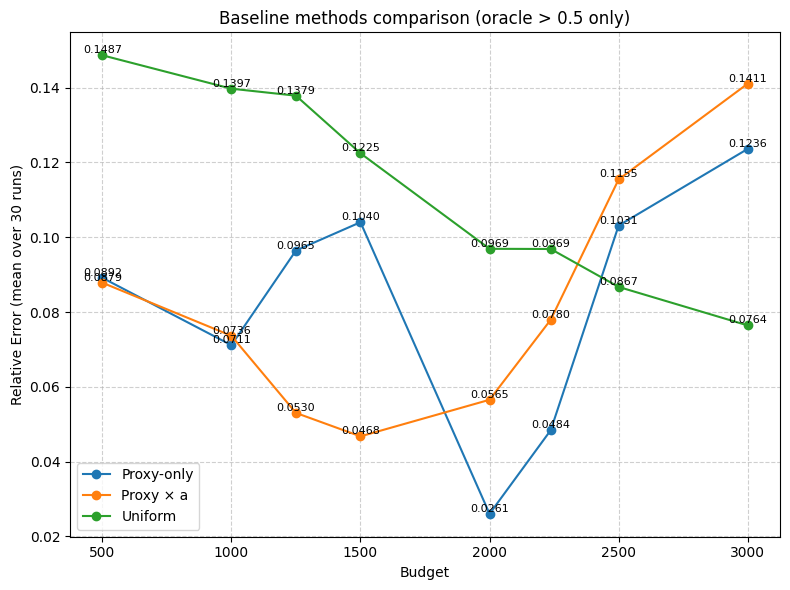

    budget   method  RelativeError
0      500  uniform       0.148662
1      500    proxy       0.089156
2      500  proxy_a       0.087850
3     1000  uniform       0.139723
4     1000    proxy       0.071146
5     1000  proxy_a       0.073650
6     1250  uniform       0.137856
7     1250    proxy       0.096454
8     1250  proxy_a       0.053034
9     1500  uniform       0.122455
10    1500    proxy       0.104020
11    1500  proxy_a       0.046768
12    2000  uniform       0.096914
13    2000    proxy       0.026063
14    2000  proxy_a       0.056548
15    2237  uniform       0.096862
16    2237    proxy       0.048416
17    2237  proxy_a       0.077952
18    2500  uniform       0.086719
19    2500    proxy       0.103130
20    2500  proxy_a       0.115472
21    3000  uniform       0.076429
22    3000    proxy       0.123625
23    3000  proxy_a       0.141069


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- 基线方法1：均匀采样 ---------
def baseline_uniform_sampling(posts: pd.DataFrame, budget: int, random_state=None):
    rng = np.random.default_rng(random_state)
    N = len(posts)
    sample = posts.sample(n=min(budget, N), random_state=rng.integers(2 << 30))

    # 真值：只统计 oracle=1 的 post
    T_true = (posts["a"] * posts["oracle"]).sum()

    # HT 估计器（均匀采样 => π_x = n/N）
    n = len(sample)
    pi = n / N
    T_hat = ((sample["a"] * sample["oracle"]) / pi).sum()

    return {"T_true": T_true, "T_hat": T_hat}


# --------- 基线方法2：proxy-only (p ∝ sqrt(proxy)) ---------
def baseline_importance_sampling_proxy(posts: pd.DataFrame, budget: int, random_state=None, eps: float = 1e-6):
    rng = np.random.default_rng(random_state)
    N = len(posts)

    # 权重 = sqrt(proxy + eps)
    weights = np.sqrt(posts["proxy"].values + eps)
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)

    if weights.sum() == 0:
        probs = np.ones(N) / N
    else:
        probs = weights / weights.sum()

    # PPS 抽样
    sample_idx = rng.choice(N, size=min(budget, N), replace=False, p=probs)
    sample = posts.iloc[sample_idx]

    # 真值
    T_true = (posts["a"] * posts["oracle"]).sum()

    # inclusion prob: π_x ≈ n * p_x
    n = len(sample)
    pi = np.minimum(1.0, n * probs[sample_idx])

    # HT估计
    T_hat = np.sum((sample["a"].values * sample["oracle"].values) / pi)

    return {"T_true": T_true, "T_hat": T_hat}


# --------- 基线方法3：proxy×a (p ∝ sqrt(proxy * a)) ---------
def baseline_importance_sampling_proxy_a(posts: pd.DataFrame, budget: int, random_state=None, eps: float = 1e-6):
    rng = np.random.default_rng(random_state)
    N = len(posts)

    # 权重 = sqrt(proxy * a + eps)
    weights = np.sqrt(posts["proxy"].values * posts["a"].values + eps)
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)

    if weights.sum() == 0:
        probs = np.ones(N) / N
    else:
        probs = weights / weights.sum()

    # PPS 抽样
    sample_idx = rng.choice(N, size=min(budget, N), replace=False, p=probs)
    sample = posts.iloc[sample_idx]

    # 真值
    T_true = (posts["a"] * posts["oracle"]).sum()

    # inclusion prob: π_x ≈ n * p_x
    n = len(sample)
    pi = np.minimum(1.0, n * probs[sample_idx])

    # HT估计
    T_hat = np.sum((sample["a"].values * sample["oracle"].values) / pi)

    return {"T_true": T_true, "T_hat": T_hat}


# --------- 对比函数 ---------
def compare_baselines(posts: pd.DataFrame, budgets=[1000, 1500, 2000], n=10):
    control_sample = 99099
    results = []
    for budget in budgets:
        for method in ["uniform", "proxy", "proxy_a"]:
            re_list = []
            for i in range(n):
                if method == "uniform":
                    out = baseline_uniform_sampling(posts, budget, random_state=i*control_sample)
                elif method == "proxy":
                    out = baseline_importance_sampling_proxy(posts, budget, random_state=i*control_sample)
                else:  # proxy_a
                    out = baseline_importance_sampling_proxy_a(posts, budget, random_state=i*control_sample)
                T_true, T_hat = out["T_true"], out["T_hat"]
                print(method,T_true, T_hat)
                re = abs(T_hat - T_true) / (T_true if T_true != 0 else 1.0)
                re_list.append(re)
            results.append({
                "budget": budget,
                "method": method,
                "RelativeError": np.mean(re_list)
            })
    
    df = pd.DataFrame(results)

    # ---- 绘图 ----
    plt.figure(figsize=(8,6))
    for method, g in df.groupby("method"):
        label = {
            "uniform": "Uniform",
            "proxy": "Proxy-only",
            "proxy_a": "Proxy × a"
        }[method]
        plt.plot(g["budget"], g["RelativeError"], marker="o", label=label)
        for x, y in zip(g["budget"], g["RelativeError"]):
            plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=8)

    plt.xlabel("Budget")
    plt.ylabel(f"Relative Error (mean over {n} runs)")
    plt.title("Baseline methods comparison (oracle > 0.5 only)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return df


# ---------- 示例 ----------
if __name__ == "__main__":
    # csv = pd.read_csv("/home/wangshuo/projects/Neo4j_Exp/pythonProject/output/query_results.csv")
    csv = pd.read_csv("/home/wangshuo/projects/FaSTest-main/dataset/sv/post_with_estimate.csv")
    # posts 数据准备
    def prepare_posts(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["estimate"] = pd.to_numeric(df["estimate"], errors="coerce").fillna(0).astype(float)
        g = df.groupby("postId", sort=False)
        posts = pd.DataFrame({
            "postId": list(g.groups.keys()),
            "a": g["estimate"].sum().values.astype(float),
            "proxy": g["post_proxy4b1"].first().values.astype(float),
            "oracle_val": g["post_oracle1"].first().values.astype(float)
        })
        posts["oracle"] = (posts["oracle_val"] > 0.5).astype(int)
        # ⭐ 按 a 降序排序
        # posts = posts.sort_values("a", ascending=False).reset_index(drop=True)
        return posts

    posts = prepare_posts(csv)
    df = compare_baselines(posts, budgets=[500, 1000, 1250,1500,2000,2237,2500,3000], n=30)
    print(df)


10
ws
proxy
hello a*proxy
Total posts: 22375, Total budget: 2237 (pilot 447 + second 1790)
Pilot allocation per stratum: {0: 112, 1: 112, 2: 111, 3: 112}

-- Method  (Proxy-only) --
Second-stage alloc: {0: 1, 1: 187, 2: 116, 3: 1487}
Pulled total (pilot + second): 2238
T_hat: 46379.233381884944 Var_hat: 11108.604028980635 95%CI: (46172.65455131963, 46585.812212450255)
Relative error: 0.006974540403077507

-- Ground truth --
True total T: 46058.0
ws
proxy
hello a*proxy
Total posts: 22375, Total budget: 2237 (pilot 447 + second 1790)
Pilot allocation per stratum: {0: 112, 1: 112, 2: 111, 3: 112}

-- Method  (Proxy-only) --
Second-stage alloc: {0: 1, 1: 113, 2: 68, 3: 1609}
Pulled total (pilot + second): 2238
T_hat: 45151.53165352637 Var_hat: 10359.843654684719 95%CI: (44952.03635186782, 45351.02695518492)
Relative error: 0.01968101842185136

-- Ground truth --
True total T: 46058.0
ws
proxy
hello a*proxy
Total posts: 22375, Total budget: 2237 (pilot 447 + second 1790)
Pilot allocation pe

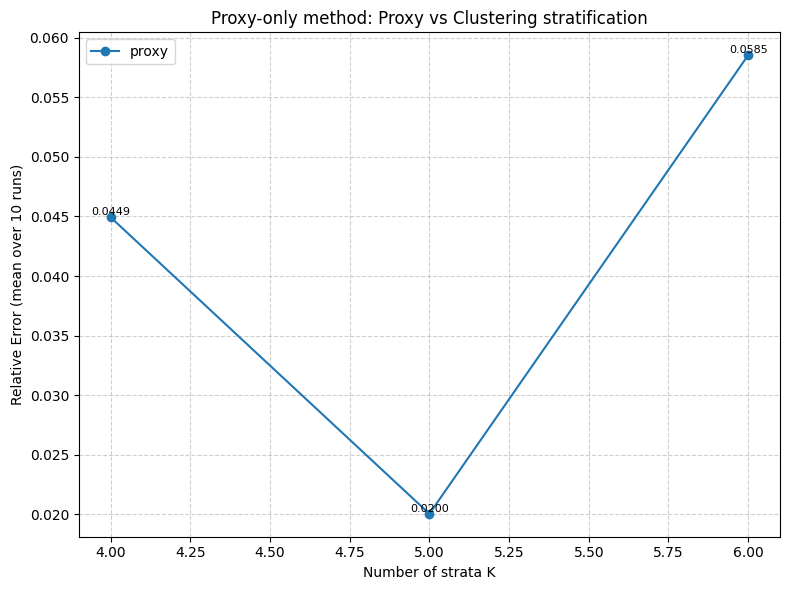

   K   mode  RelativeError
0  4  proxy       0.044927
1  5  proxy       0.020047
2  6  proxy       0.058526


In [37]:
# ablation_proxy_vs_w.py
import math
import numpy as np
import pandas as pd
from typing import Tuple, Dict
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(4700050)

# ----------------------------
# Helper: prepare posts from raw rows
# ----------------------------
def prepare_posts(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # ensure numeric
    df["comment_upvotes"] = pd.to_numeric(df["comment_upvotes"], errors="coerce").fillna(0).astype(float)
    g = df.groupby("postId", sort=False)
    posts = pd.DataFrame({
        "postId": list(g.groups.keys()),
        # w: number of matches (occurrence count)
        "w": g.size().values.astype(float),
        # a: total contribution (sum of comment_upvotes)
        "a": g["comment_upvotes"].sum().values.astype(float),
        # proxy and oracle take first (assume same per post)
        "proxy": g["post_proxy2b1"].first().values.astype(float),
        "oracle_val": g["post_oracle1"].first().values.astype(float)
    })
    posts["oracle"] = (posts["oracle_val"] > 0.5).astype(int)
    return posts

# ----------------------------
# Base stratified sampler utilities
# ----------------------------
def stratify_by_proxy(posts: pd.DataFrame, K: int) -> pd.DataFrame:
    posts = posts.copy()
    # try qcut, fallback to rank-based
    try:
        posts["stratum"] = pd.qcut(posts["proxy"], K, labels=False, duplicates="drop")
    except Exception:
        posts["stratum"] = pd.cut(posts["proxy"].rank(method="first"), bins=K, labels=False)
    if posts["stratum"].isnull().any():
        posts["stratum"] = posts["stratum"].fillna(0)
    posts["stratum"] = posts["stratum"].astype(int)
    return posts


def stratify_by_clustering(posts: pd.DataFrame, K: int, use_features=("proxy", "a")) -> pd.DataFrame:
    """
    用 KMeans 在指定特征上聚类。默认使用 ('proxy','a')（对 a 做 log1p 并标准化）。
    备注：返回的 posts 带有整型 'stratum' 字段。
    """
    posts = posts.copy()
    Xcols = []
    X = []
    if "proxy" in use_features:
        Xcols.append("proxy")
        X.append(posts["proxy"].values.reshape(-1,1))
    if "a" in use_features:
        Xcols.append("log1p_a")
        X.append(np.log1p(posts["a"].values).reshape(-1,1))
    if "w" in use_features:
        Xcols.append("log1p_w")
        X.append(np.log1p(posts["w"].values).reshape(-1,1))

    if len(X) == 0:
        raise ValueError("No features selected for clustering")

    X = np.hstack(X)
    # 标准化（重要）
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    posts["stratum"] = km.fit_predict(Xs).astype(int)
    # 统计每个簇的大小
    cluster_counts = posts["stratum"].value_counts().sort_index().to_dict()

    # 打印输出
    print("每个簇的元素个数：")
    for k, count in cluster_counts.items():
        print(f"簇 {k}: {count} 个元素")
    return posts

def stratify_by_expected_contrib(posts: pd.DataFrame, K: int) -> pd.DataFrame:
    """
    简单且语义清晰的做法：按 proxy * a（期望贡献）做分位切分（qcut）。
    适合 SUM 估计，且解释性好。
    """
    posts = posts.copy()
    # expected contribution
    posts["exp_contrib"] = posts["proxy"] * posts["a"]
    # 若 exp_contrib 全部为 0 或重复较多，qcut 可能抛错 -> fallback to rank-based cut
    try:
        posts["stratum"] = pd.qcut(posts["exp_contrib"], K, labels=False, duplicates="drop")
    except Exception:
        # use rank-based cut
        posts["stratum"] = pd.cut(posts["exp_contrib"].rank(method="first"), bins=K, labels=False)
    posts["stratum"] = posts["stratum"].fillna(0).astype(int)
    return posts

# ----------------------------
# Pilot allocation helper (把 pilot 总预算 N1_total 分配到每个层)
# ----------------------------
def allocate_pilot_budget_per_stratum(stats: Dict[int, dict], N1_total: int, min_per_stratum: int = 1) -> Dict[int, int]:
    """
    将 pilot 总预算 N1_total 按层大小 N_k 比例分配，结果为每层 n1_k（整数）。
    策略：
      - 首先按 N_k / N_total 计算连续比例 cont_k
      - 取 floor(cont_k) 作为初始分配
      - 将剩余名额按小数部分从大到小分配
      - 保证每层至少 min_per_stratum（如果可能）且不超过该层容量 N_k
    """
    if N1_total <= 0:
        return {k: 0 for k in stats}
    Nks = {k: st["N_k"] for k, st in stats.items()}
    total_N = sum(Nks.values())
    if total_N == 0:
        return {k: 0 for k in stats}
    # preliminary continuous allocation
    cont = {k: (N1_total * Nks[k] / total_N) for k in Nks}
    floored = {k: int(math.floor(v)) for k, v in cont.items()}
    assigned = sum(floored.values())
    rem = N1_total - assigned
    # fractional parts sorted descending
    fracs = sorted(((k, cont[k] - floored[k]) for k in cont), key=lambda x: x[1], reverse=True)
    alloc = floored.copy()
    idx = 0
    while rem > 0 and idx < len(fracs):
        k = fracs[idx][0]
        alloc[k] += 1
        rem -= 1
        idx += 1
    # ensure min_per_stratum where possible
    for k in alloc:
        if Nks[k] == 0:
            alloc[k] = 0
        else:
            alloc[k] = max(0, min(alloc[k], Nks[k]))  # cap at N_k
    # If some strata got 0 but we want min_per_stratum, try to enforce (if budget allows)
    if min_per_stratum > 0:
        want = {k: max(min_per_stratum, alloc[k]) if Nks[k] > 0 else 0 for k in alloc}
        sum_want = sum(want.values())
        if sum_want <= N1_total:
            alloc = want
        else:
            # cannot satisfy min for all; keep current alloc (already sum==N1_total)
            pass
    return alloc

# ----------------------------
# Pilot stats using per-stratum pilot allocation
# ----------------------------
def pilot_stats_with_alloc(posts: pd.DataFrame, pilot_alloc: Dict[int,int]) -> Tuple[Dict[int, dict], Dict[int, pd.DataFrame]]:
    stats = {}
    pilots = {}
    for k, grp in posts.groupby("stratum"):
        Nk = len(grp)
        n1 = int(min(pilot_alloc.get(k, 0), Nk))
        if n1 <= 0:
            stats[k] = {"W_k": float(grp["a"].sum()), "p_hat": 0.0, "sigma_hat": 0.0, "N_k": Nk, "n1": 0}
            pilots[k] = pd.DataFrame(columns=posts.columns)
            continue
        sample = grp.sample(n1, replace=False, random_state=np.random.randint(1<<30))
        sample = sample.copy()
        sample["Y"] = sample["a"] * sample["oracle"]  # observed contribution
        W_k_sample = sample["a"].sum()
        W_pos = sample.loc[sample["oracle"] == 1, "a"].sum()
        p_hat = (W_pos / W_k_sample) if W_k_sample > 0 else (sample["oracle"].mean() if len(sample)>0 else 0.0)
        sigma_hat = sample["Y"].std(ddof=1) if len(sample) > 1 else 0.0
        W_k = grp["a"].sum()
        stats[k] = {"W_k": float(W_k), "p_hat": float(p_hat), "sigma_hat": float(sigma_hat), "N_k": Nk, "n1": n1}
        pilots[k] = sample
    return stats, pilots

# ----------------------------
# Allocation functions but scaled to a given second-stage budget N2
# ----------------------------

def allocate_proxy_only_given_N2_with_redist(
    stats: Dict[int, dict],
    N2: int,
    alpha: float=1.0,
    beta: float=1.0,
    min_per_stratum: int=1
) -> Dict[int,int]:
    """
    Proxy-only 第二阶段分配（带再分配机制）。
    - 初步分配：按 sqrt(p_tilde * sigma_hat) 做 Neyman 分配
    - 截断：不能超过该层剩余容量 (N_k - n1)
    - 再分配：把多余的预算继续按照权重分配到剩余层
    """
    if N2 <= 0:
        return {k: 0 for k in stats}

    # --- Step 1. 计算每层权重 ---
    weights = {}
    for k, st in stats.items():
        n1 = st.get("n1", 0)
        if n1 > 0:
            p_tilde = (st["p_hat"] * n1 + alpha) / (n1 + alpha + beta)
        else:
            p_tilde = alpha / (alpha + beta)
        val = math.sqrt(max(1e-12, p_tilde) * max(1e-12, st["sigma_hat"]))
        weights[k] = val

    alloc = {k: 0 for k in stats}

    remaining_budget = N2
    remaining_strata = set(stats.keys())

    # --- Step 2. 循环再分配 ---
    while remaining_budget > 0 and remaining_strata:
        # 提取可用层（还有剩余容量）
        feasible_strata = []
        feasible_weights = {}
        for k in remaining_strata:
            st = stats[k]
            max_add = max(0, st["N_k"] - st.get("n1", 0) - alloc[k])
            if max_add > 0 and weights[k] > 0:
                feasible_strata.append(k)
                feasible_weights[k] = weights[k]

        if not feasible_strata:
            break  # 没有层能再分配了

        # 按权重分配
        total_w = sum(feasible_weights.values())
        cont = {k: remaining_budget * feasible_weights[k] / total_w for k in feasible_strata}
        floored = {k: int(math.floor(v)) for k, v in cont.items()}
        assigned = sum(floored.values())
        rem = remaining_budget - assigned

        # 初步加上
        for k in floored:
            alloc[k] += floored[k]

        # 小数部分分配
        fracs = sorted(((k, cont[k] - floored[k]) for k in feasible_strata),
                       key=lambda x: x[1], reverse=True)
        idx = 0
        while rem > 0 and idx < len(fracs):
            alloc[fracs[idx][0]] += 1
            rem -= 1
            idx += 1

        # --- Step 3. 截断超出容量的层 ---
        over = {}
        for k in feasible_strata:
            st = stats[k]
            max_add = max(0, st["N_k"] - st.get("n1", 0))
            if alloc[k] > max_add:
                over[k] = alloc[k] - max_add
                alloc[k] = max_add

        # 计算新剩余预算
        used_now = assigned + (remaining_budget - assigned - rem)  # 本轮实际用掉
        refunded = sum(over.values())
        remaining_budget = rem + refunded

        # 更新还没抽满的层
        remaining_strata = {k for k in feasible_strata if alloc[k] < (stats[k]["N_k"] - stats[k].get("n1",0))}

    # --- Step 4. min_per_stratum 约束 ---
    for k, st in stats.items():
        if st["N_k"] > st.get("n1",0):  # 层有容量
            alloc[k] = max(alloc[k], min_per_stratum)

    return alloc

# ----------------------------
# Second stage + estimation (same for both methods)
# ----------------------------
def second_stage_and_estimate(posts: pd.DataFrame, pilots: Dict[int,pd.DataFrame], alloc: Dict[int,int]) -> Tuple[Dict,int, Dict]:
    """
    For each stratum, sample alloc[k] additional posts using importance sampling (PPS ∝ sqrt(proxy*a)),
    combine with pilot, compute Y=a*oracle, and use HT estimator for unbiasedness.
    """
    combined = {}
    summaries = {}
    total_pulled = 0
    for k, grp in posts.groupby("stratum"):
        pilot = pilots.get(k, pd.DataFrame(columns=posts.columns))
        pilot_ids = set(pilot["postId"].tolist()) if not pilot.empty else set()
        remaining_grp = grp[~grp["postId"].isin(pilot_ids)]
        add_n = alloc.get(k, 0)
        add_sample = pd.DataFrame(columns=posts.columns)

        if add_n > 0 and len(remaining_grp) > 0:
            # ---- 重要性采样权重 ∝ sqrt(proxy * a) ----
            weights = np.sqrt(remaining_grp["proxy"].values * remaining_grp["a"].values + 1e-6)
            weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
            if weights.sum() == 0:
                probs = np.ones(len(remaining_grp)) / len(remaining_grp)
            else:
                probs = weights / weights.sum()

            rng = np.random.default_rng(np.random.randint(1<<30))
            sample_idx = rng.choice(len(remaining_grp), size=min(add_n, len(remaining_grp)), replace=False, p=probs)
            add_sample = remaining_grp.iloc[sample_idx].copy()

            # inclusion probability π ≈ n * p_x （截断在1）
            n = len(add_sample)
            pi = np.minimum(1.0, n * probs[sample_idx])
            add_sample["pi"] = pi

        # 合并 pilot + second stage
        final = pd.concat([pilot, add_sample], ignore_index=True, sort=False).copy()
        if final.empty:
            summaries[k] = {"n_k":0, "N_k": len(grp), "T_hat":0.0, "Var_hat":0.0}
            combined[k] = final
            continue

        final["Y"] = final["a"] * final["oracle"]

        # ---- Horvitz–Thompson estimator ----
        if "pi" not in final:
            # pilot 样本是均匀的: π = n1 / N_k
            pi_pilot = len(pilot) / len(grp) if len(grp)>0 else 1.0
            final["pi"] = pi_pilot

        T_hat_k = np.sum(final["Y"] / final["pi"])
        # 方差估计（近似，用HT样本内方差）
        Var_hat_k = final["Y"].var(ddof=1) if len(final)>1 else 0.0

        total_pulled += len(final)
        combined[k] = final
        summaries[k] = {"n_k": len(final), "N_k": len(grp), "T_hat": T_hat_k, "Var_hat": Var_hat_k}

    # 聚合所有层的估计
    T_hat = sum(v["T_hat"] for v in summaries.values())
    Var_hat = sum(v["Var_hat"] for v in summaries.values())  # 粗略相加
    se = math.sqrt(max(0.0, Var_hat))
    ci_low, ci_high = T_hat - 1.96 * se, T_hat + 1.96 * se

    return summaries, total_pulled, {"T_hat": float(T_hat), "Var_hat": float(Var_hat), "CI": (ci_low, ci_high)}

# ----------------------------
# Driver: run both methods and compare (现在支持 c_stage 控制)
# ----------------------------
def run_ablation(csv_path: str, stratify_mode="proxy",
                 K: int=5,
                 c_stage: float=0.4, total_budget_frac:float=0.15, min_pilot_per_stratum:int=1):
    """
    c_stage: pilot stage 占总预算的比例 (0..1). 例如 c_stage=0.4 表示 pilot 使用总预算的 40%（整数计数）。
    total_budget_frac: 总预算占总 posts 的比例（两个阶段之和）。
    min_pilot_per_stratum: pilot 分配时对有容量层的最小保障（若预算充足）。
    """
    df = pd.read_csv(csv_path)
    posts = prepare_posts(df)
    print(stratify_mode)
    # Stratify
    if stratify_mode == "proxy":
        # posts = stratify_by_proxy(posts, K=K)
        print('hello a*proxy')
        posts = stratify_by_expected_contrib(posts, K=K)
    elif stratify_mode == "clustering":
        print('hello (proxy,a)')
        posts = stratify_by_clustering(posts, K=K, use_features=("proxy", "a"))
    else:
        raise ValueError("Unknown stratify_mode")

    # compute overall budgets
    N_total = int(math.floor(total_budget_frac * len(posts)))
    N1_total = int(math.floor(c_stage * N_total))
    N2 = max(0, N_total - N1_total)

    # Safety: ensure budgets are within total posts
    N_total = min(N_total, len(posts))
    N1_total = min(N1_total, N_total)
    N2 = N_total - N1_total

    # ----------------------------
    # Pilot: 将 N1_total 按层分配
    # ----------------------------
    # need initial stats only for N_k (we can compute N_k per stratum from posts)
    stats_init = {}
    for k, grp in posts.groupby("stratum"):
        stats_init[k] = {"N_k": len(grp), "W_k": float(grp["a"].sum())}

    pilot_alloc = allocate_pilot_budget_per_stratum(stats_init, N1_total, min_per_stratum=min_pilot_per_stratum)
    # print pilot allocation
    print(f"Total posts: {len(posts)}, Total budget: {N_total} (pilot {N1_total} + second {N2})")
    print("Pilot allocation per stratum:", pilot_alloc)

    # draw pilot samples according to pilot_alloc
    stats, pilots = pilot_stats_with_alloc(posts, pilot_alloc)

    # ----------------------------
    # Second-stage: 使用 stats（含 pilot 信息）计算 allocation，且把第二阶段预算限制为 N2
    # ----------------------------
    # Method B: Proxy-only allocation using N2
    alloc_p = allocate_proxy_only_given_N2_with_redist(stats, N2, alpha=1.0, beta=1.0, min_per_stratum=1)

    # Run second stage and estimation
    summaries_p, total_pulled_p, res_p = second_stage_and_estimate(posts, pilots, alloc_p)

    T_true = float((posts["a"] * posts["oracle"]).sum())
    re_p = abs(res_p["T_hat"] - T_true) / (T_true if T_true != 0 else 1.0)

    # Print comparison
    print("\n-- Method  (Proxy-only) --")
    print("Second-stage alloc:", alloc_p)
    print("Pulled total (pilot + second):", total_pulled_p)
    print("T_hat:", res_p["T_hat"], "Var_hat:", res_p["Var_hat"], "95%CI:", res_p["CI"])
    print("Relative error:", re_p)
    print("\n-- Ground truth --")
    print("True total T:", T_true)

    return {
        "posts": posts,
        "stats": stats,
        "pilots": pilots,
        "pilot_alloc": pilot_alloc,
        "proxy_method": {"alloc": alloc_p, "result": res_p, "summaries": summaries_p},
        "T_true": T_true,
        "N_total": N_total,
        "N1_total": N1_total,
        "N2": N2
    }


def compare_strat_methods(csv_path: str, Ks=range(2, 11),
                          c_stage: float=0.4, total_budget_frac: float=0.15,
                          n: int=1):
    print(n)
    """
    比较 proxy-stratify 和 clustering-stratify 在不同 K 下的 proxy-only 误差表现。
    每个设置运行 n 次，取均值作为最终结果。
    """
    results = []
    for K in Ks:
        for mode in ["proxy"]:
            re_list = []
            for i in range(n):
                print('ws')
                # 每次运行用不同随机种子
                np.random.seed(np.random.randint(0, 1 << 30))
                out = run_ablation(
                    csv_path, stratify_mode=mode, K=K,
                    c_stage=c_stage, total_budget_frac=total_budget_frac,
                    min_pilot_per_stratum=1
                )
                T_true = out["T_true"]
                T_hat = out["proxy_method"]["result"]["T_hat"]
                re = abs(T_hat - T_true) / (T_true if T_true != 0 else 1.0)
                re_list.append(re)

        # 去掉最大值和最小值再取均值
        if len(re_list) > 2:
            re_list_sorted = sorted(re_list)
            re_mean = np.mean(re_list_sorted[1:-1])
        else:
            re_mean = np.mean(re_list)

        results.append({"K": K, "mode": mode, "RelativeError": re_mean})

    df = pd.DataFrame(results)

    # ---- 绘制折线图 ----
    plt.figure(figsize=(8,6))
    for mode, g in df.groupby("mode"):
        plt.plot(g["K"], g["RelativeError"], marker="o", label=mode)
        # 在点上标注 4 位小数
        for x, y in zip(g["K"], g["RelativeError"]):
            plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=8)

    plt.xlabel("Number of strata K")
    plt.ylabel("Relative Error (mean over {} runs)".format(n))
    plt.title("Proxy-only method: Proxy vs Clustering stratification")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return df


if __name__ == "__main__":
    csv_path = "/home/wangshuo/projects/Neo4j_Exp/pythonProject/output/query_results.csv"
    df_res = compare_strat_methods(csv_path, Ks=range(4, 7),
                                   c_stage=0.2, total_budget_frac=0.1,n=10)
    print(df_res)




=== Stratify=proxy, Sampling=importance ===
[proxy]
Second-stage alloc: {0: 1, 1: 1, 2: 895}
Pulled total (pilot + second): 1120
T_hat: 42841.25478354772 Var_hat: 18001.794004639698 95%CI: (42578.28008543358, 43104.22948166187)
Relative error: 0.06984118321360624
True total T: 46058.0
=== Stratify=proxy, Sampling=importance ===
[proxy]
Second-stage alloc: {0: 22, 1: 1, 2: 873}
Pulled total (pilot + second): 1119
T_hat: 42779.83314817851 Var_hat: 17872.888531593842 95%CI: (42517.801683306505, 43041.86461305052)
Relative error: 0.07117475469671906
True total T: 46058.0
=== Stratify=proxy, Sampling=importance ===
[proxy]
Second-stage alloc: {0: 1, 1: 1, 2: 895}
Pulled total (pilot + second): 1120
T_hat: 44352.94106976442 Var_hat: 17972.94631510716 95%CI: (44090.17716325495, 44615.70497627389)
Relative error: 0.037019821317373316
True total T: 46058.0
=== Stratify=proxy, Sampling=importance ===
[proxy]
Second-stage alloc: {0: 24, 1: 50, 2: 821}
Pulled total (pilot + second): 1118
T_hat: 46

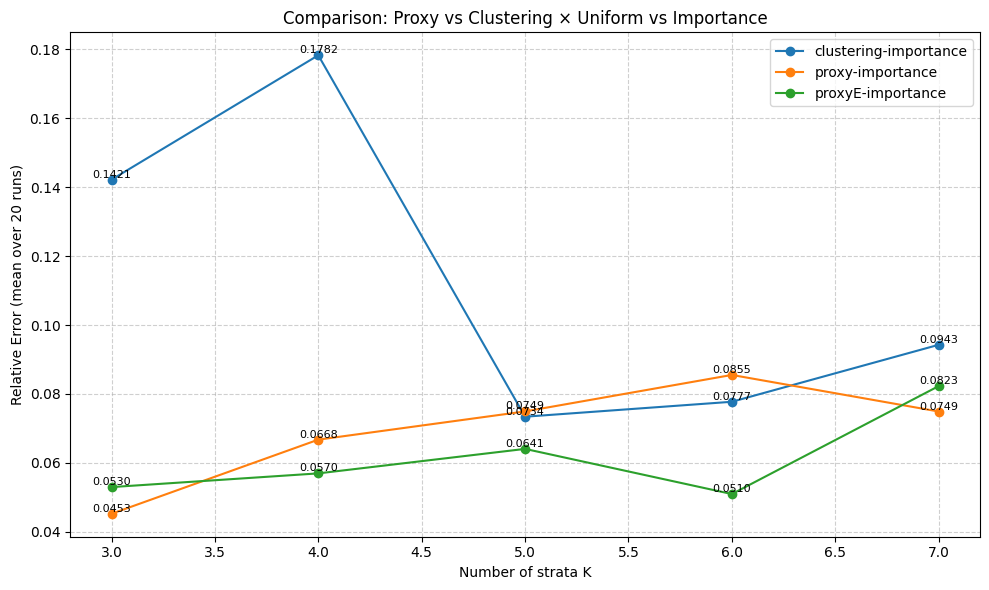


最终结果 DataFrame：
    K        mode    sampling  RelativeError
0   3       proxy  importance       0.045252
1   3      proxyE  importance       0.052996
2   3  clustering  importance       0.142145
3   4       proxy  importance       0.066753
4   4      proxyE  importance       0.056972
5   4  clustering  importance       0.178224
6   5       proxy  importance       0.074939
7   5      proxyE  importance       0.064073
8   5  clustering  importance       0.073405
9   6       proxy  importance       0.085517
10  6      proxyE  importance       0.050982
11  6  clustering  importance       0.077738
12  7       proxy  importance       0.074916
13  7      proxyE  importance       0.082279
14  7  clustering  importance       0.094257


In [3]:
# ablation_proxy_vs_w.py
import math
import numpy as np
import pandas as pd
from typing import Tuple, Dict
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(4700050)

# ----------------------------
# Helper: prepare posts from raw rows
# ----------------------------
def prepare_posts(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # ensure numeric
    df["comment_upvotes"] = pd.to_numeric(df["comment_upvotes"], errors="coerce").fillna(0).astype(float)
    g = df.groupby("postId", sort=False)
    posts = pd.DataFrame({
        "postId": list(g.groups.keys()),
        # w: number of matches (occurrence count)
        "w": g.size().values.astype(float),
        # a: total contribution (sum of comment_upvotes)
        "a": g["comment_upvotes"].sum().values.astype(float),
        # proxy and oracle take first (assume same per post)
        "proxy": g["post_proxy4b1"].first().values.astype(float),
        "oracle_val": g["post_oracle1"].first().values.astype(float)
    })
    posts["oracle"] = (posts["oracle_val"] > 0.5).astype(int)
    return posts

# ----------------------------
# Base stratified sampler utilities
# ----------------------------
def stratify_by_proxy(posts: pd.DataFrame, K: int) -> pd.DataFrame:
    posts = posts.copy()
    # try qcut, fallback to rank-based
    try:
        posts["stratum"] = pd.qcut(posts["proxy"], K, labels=False, duplicates="drop")
    except Exception:
        posts["stratum"] = pd.cut(posts["proxy"].rank(method="first"), bins=K, labels=False)
    if posts["stratum"].isnull().any():
        posts["stratum"] = posts["stratum"].fillna(0)
    posts["stratum"] = posts["stratum"].astype(int)
    return posts


def stratify_by_clustering(posts: pd.DataFrame, K: int, use_features=("proxy", "a")) -> pd.DataFrame:
    """
    用 KMeans 在指定特征上聚类。默认使用 ('proxy','a')（对 a 做 log1p 并标准化）。
    备注：返回的 posts 带有整型 'stratum' 字段。
    """
    posts = posts.copy()
    Xcols = []
    X = []
    if "proxy" in use_features:
        Xcols.append("proxy")
        X.append(posts["proxy"].values.reshape(-1,1))
    if "a" in use_features:
        Xcols.append("log1p_a")
        X.append(np.log1p(posts["a"].values).reshape(-1,1))
    if "w" in use_features:
        Xcols.append("log1p_w")
        X.append(np.log1p(posts["w"].values).reshape(-1,1))

    if len(X) == 0:
        raise ValueError("No features selected for clustering")

    X = np.hstack(X)
    # 标准化（重要）
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    posts["stratum"] = km.fit_predict(Xs).astype(int)
    # 统计每个簇的大小
    cluster_counts = posts["stratum"].value_counts().sort_index().to_dict()

    # 打印输出
    print("每个簇的元素个数：")
    for k, count in cluster_counts.items():
        print(f"簇 {k}: {count} 个元素")
    return posts

def stratify_by_expected_contrib(posts: pd.DataFrame, K: int) -> pd.DataFrame:
    """
    简单且语义清晰的做法：按 proxy * a（期望贡献）做分位切分（qcut）。
    适合 SUM 估计，且解释性好。
    """
    posts = posts.copy()
    # expected contribution
    posts["exp_contrib"] = posts["proxy"] * posts["a"]
    # 若 exp_contrib 全部为 0 或重复较多，qcut 可能抛错 -> fallback to rank-based cut
    try:
        posts["stratum"] = pd.qcut(posts["exp_contrib"], K, labels=False, duplicates="drop")
    except Exception:
        # use rank-based cut
        posts["stratum"] = pd.cut(posts["exp_contrib"].rank(method="first"), bins=K, labels=False)
    posts["stratum"] = posts["stratum"].fillna(0).astype(int)
    return posts

# ----------------------------
# Pilot allocation helper (把 pilot 总预算 N1_total 分配到每个层)
# ----------------------------
def allocate_pilot_budget_per_stratum(stats: Dict[int, dict], N1_total: int, min_per_stratum: int = 1) -> Dict[int, int]:
    """
    将 pilot 总预算 N1_total 按层大小 N_k 比例分配，结果为每层 n1_k（整数）。
    策略：
      - 首先按 N_k / N_total 计算连续比例 cont_k
      - 取 floor(cont_k) 作为初始分配
      - 将剩余名额按小数部分从大到小分配
      - 保证每层至少 min_per_stratum（如果可能）且不超过该层容量 N_k
    """
    if N1_total <= 0:
        return {k: 0 for k in stats}
    Nks = {k: st["N_k"] for k, st in stats.items()}
    total_N = sum(Nks.values())
    if total_N == 0:
        return {k: 0 for k in stats}
    # preliminary continuous allocation
    cont = {k: (N1_total * Nks[k] / total_N) for k in Nks}
    floored = {k: int(math.floor(v)) for k, v in cont.items()}
    assigned = sum(floored.values())
    rem = N1_total - assigned
    # fractional parts sorted descending
    fracs = sorted(((k, cont[k] - floored[k]) for k in cont), key=lambda x: x[1], reverse=True)
    alloc = floored.copy()
    idx = 0
    while rem > 0 and idx < len(fracs):
        k = fracs[idx][0]
        alloc[k] += 1
        rem -= 1
        idx += 1
    # ensure min_per_stratum where possible
    for k in alloc:
        if Nks[k] == 0:
            alloc[k] = 0
        else:
            alloc[k] = max(0, min(alloc[k], Nks[k]))  # cap at N_k
    # If some strata got 0 but we want min_per_stratum, try to enforce (if budget allows)
    if min_per_stratum > 0:
        want = {k: max(min_per_stratum, alloc[k]) if Nks[k] > 0 else 0 for k in alloc}
        sum_want = sum(want.values())
        if sum_want <= N1_total:
            alloc = want
        else:
            # cannot satisfy min for all; keep current alloc (already sum==N1_total)
            pass
    return alloc

# ----------------------------
# Pilot stats using per-stratum pilot allocation
# ----------------------------
def pilot_stats_with_alloc(posts: pd.DataFrame, pilot_alloc: Dict[int,int]) -> Tuple[Dict[int, dict], Dict[int, pd.DataFrame]]:
    stats = {}
    pilots = {}
    for k, grp in posts.groupby("stratum"):
        Nk = len(grp)
        n1 = int(min(pilot_alloc.get(k, 0), Nk))
        if n1 <= 0:
            stats[k] = {"W_k": float(grp["a"].sum()), "p_hat": 0.0, "sigma_hat": 0.0, "N_k": Nk, "n1": 0}
            pilots[k] = pd.DataFrame(columns=posts.columns)
            continue
        sample = grp.sample(n1, replace=False, random_state=np.random.randint(1<<30))
        sample = sample.copy()
        sample["Y"] = sample["a"] * sample["oracle"]  # observed contribution
        W_k_sample = sample["a"].sum()
        W_pos = sample.loc[sample["oracle"] == 1, "a"].sum()
        p_hat = (W_pos / W_k_sample) if W_k_sample > 0 else (sample["oracle"].mean() if len(sample)>0 else 0.0)
        sigma_hat = sample["Y"].std(ddof=1) if len(sample) > 1 else 0.0
        W_k = grp["a"].sum()
        stats[k] = {"W_k": float(W_k), "p_hat": float(p_hat), "sigma_hat": float(sigma_hat), "N_k": Nk, "n1": n1}
        pilots[k] = sample
    return stats, pilots

# ----------------------------
# Allocation functions but scaled to a given second-stage budget N2
# ----------------------------

def allocate_proxy_only_given_N2_with_redist(
    stats: Dict[int, dict],
    N2: int,
    alpha: float=1.0,
    beta: float=1.0,
    min_per_stratum: int=1
) -> Dict[int,int]:
    """
    Proxy-only 第二阶段分配（带再分配机制）。
    - 初步分配：按 sqrt(p_tilde * sigma_hat) 做 Neyman 分配
    - 截断：不能超过该层剩余容量 (N_k - n1)
    - 再分配：把多余的预算继续按照权重分配到剩余层
    """
    if N2 <= 0:
        return {k: 0 for k in stats}

    # --- Step 1. 计算每层权重 ---
    weights = {}
    for k, st in stats.items():
        n1 = st.get("n1", 0)
        if n1 > 0:
            p_tilde = (st["p_hat"] * n1 + alpha) / (n1 + alpha + beta)
        else:
            p_tilde = alpha / (alpha + beta)
        val = math.sqrt(max(1e-12, p_tilde) * max(1e-12, st["sigma_hat"]))
        weights[k] = val

    alloc = {k: 0 for k in stats}

    remaining_budget = N2
    remaining_strata = set(stats.keys())

    # --- Step 2. 循环再分配 ---
    while remaining_budget > 0 and remaining_strata:
        # 提取可用层（还有剩余容量）
        feasible_strata = []
        feasible_weights = {}
        for k in remaining_strata:
            st = stats[k]
            max_add = max(0, st["N_k"] - st.get("n1", 0) - alloc[k])
            if max_add > 0 and weights[k] > 0:
                feasible_strata.append(k)
                feasible_weights[k] = weights[k]

        if not feasible_strata:
            break  # 没有层能再分配了

        # 按权重分配
        total_w = sum(feasible_weights.values())
        cont = {k: remaining_budget * feasible_weights[k] / total_w for k in feasible_strata}
        floored = {k: int(math.floor(v)) for k, v in cont.items()}
        assigned = sum(floored.values())
        rem = remaining_budget - assigned

        # 初步加上
        for k in floored:
            alloc[k] += floored[k]

        # 小数部分分配
        fracs = sorted(((k, cont[k] - floored[k]) for k in feasible_strata),
                       key=lambda x: x[1], reverse=True)
        idx = 0
        while rem > 0 and idx < len(fracs):
            alloc[fracs[idx][0]] += 1
            rem -= 1
            idx += 1

        # --- Step 3. 截断超出容量的层 ---
        over = {}
        for k in feasible_strata:
            st = stats[k]
            max_add = max(0, st["N_k"] - st.get("n1", 0))
            if alloc[k] > max_add:
                over[k] = alloc[k] - max_add
                alloc[k] = max_add

        # 计算新剩余预算
        used_now = assigned + (remaining_budget - assigned - rem)  # 本轮实际用掉
        refunded = sum(over.values())
        remaining_budget = rem + refunded

        # 更新还没抽满的层
        remaining_strata = {k for k in feasible_strata if alloc[k] < (stats[k]["N_k"] - stats[k].get("n1",0))}

    # --- Step 4. min_per_stratum 约束 ---
    for k, st in stats.items():
        if st["N_k"] > st.get("n1",0):  # 层有容量
            alloc[k] = max(alloc[k], min_per_stratum)

    return alloc

# ----------------------------
# Second stage + estimation (same for both methods)
# ----------------------------
def second_stage_and_estimate(
    posts: pd.DataFrame, 
    pilots: Dict[int,pd.DataFrame], 
    alloc: Dict[int,int],
    sampling: str = "uniform"   # 新增参数
) -> Tuple[Dict,int, Dict]:
    """
    For each stratum, sample alloc[k] additional posts.
    - sampling="uniform": 层内均匀抽样
    - sampling="importance": 层内重要性采样 (PPS ∝ sqrt(proxy*a))
    """
    combined = {}
    summaries = {}
    total_pulled = 0

    for k, grp in posts.groupby("stratum"):
        pilot = pilots.get(k, pd.DataFrame(columns=posts.columns))
        pilot_ids = set(pilot["postId"].tolist()) if not pilot.empty else set()
        remaining_grp = grp[~grp["postId"].isin(pilot_ids)]
        add_n = alloc.get(k, 0)
        add_sample = pd.DataFrame(columns=posts.columns)

        if add_n > 0 and len(remaining_grp) > 0:
            if sampling == "uniform":
                add_sample = remaining_grp.sample(min(add_n, len(remaining_grp)), replace=False,
                                                  random_state=np.random.randint(1<<30)).copy()
                # 均匀采样 π = n / N
                pi = len(add_sample) / len(remaining_grp)
                add_sample["pi"] = pi

            elif sampling == "importance":
                weights = np.sqrt(remaining_grp["proxy"].values * remaining_grp["a"].values + 1e-6)
                weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
                probs = weights / weights.sum() if weights.sum() > 0 else np.ones(len(remaining_grp))/len(remaining_grp)

                rng = np.random.default_rng(np.random.randint(1<<30))
                sample_idx = rng.choice(len(remaining_grp), size=min(add_n, len(remaining_grp)),
                                        replace=False, p=probs)
                add_sample = remaining_grp.iloc[sample_idx].copy()

                n = len(add_sample)
                pi = np.minimum(1.0, n * probs[sample_idx])  # inclusion prob
                add_sample["pi"] = pi

        # --- 合并 ---
        final = pd.concat([pilot, add_sample], ignore_index=True, sort=False).copy()
        if final.empty:
            summaries[k] = {"n_k":0, "N_k": len(grp), "T_hat":0.0, "Var_hat":0.0}
            combined[k] = final
            continue

        final["Y"] = final["a"] * final["oracle"]

        if "pi" not in final:
            pi_pilot = len(pilot) / len(grp) if len(grp) > 0 else 1.0
            final["pi"] = pi_pilot

        # Horvitz–Thompson 估计
        T_hat_k = np.sum(final["Y"] / final["pi"])
        Var_hat_k = final["Y"].var(ddof=1) if len(final)>1 else 0.0

        total_pulled += len(final)
        combined[k] = final
        summaries[k] = {"n_k": len(final), "N_k": len(grp), "T_hat": T_hat_k, "Var_hat": Var_hat_k}

    # ---- 聚合 ----
    T_hat = sum(v["T_hat"] for v in summaries.values())
    Var_hat = sum(v["Var_hat"] for v in summaries.values())
    se = math.sqrt(max(0.0, Var_hat))
    ci_low, ci_high = T_hat - 1.96*se, T_hat + 1.96*se

    return summaries, total_pulled, {"T_hat": float(T_hat), "Var_hat": float(Var_hat), "CI": (ci_low, ci_high)}

# ----------------------------
# Driver: run both methods and compare (现在支持 c_stage 控制)
# ----------------------------
def run_ablation(csv_path: str, stratify_mode="proxy", K: int = 5,
                 c_stage: float = 0.4, total_budget_frac: float = 0.15,
                 min_pilot_per_stratum: int = 1,
                 sampling: str = "uniform"):
    """
    stratify_mode: "proxy" or "clustering"
    sampling: "uniform" or "importance" (层内采样方式)
    """
    df = pd.read_csv(csv_path)
    posts = prepare_posts(df)
    print(f"=== Stratify={stratify_mode}, Sampling={sampling} ===")

    # ---------------------------- Stratify ----------------------------
    if stratify_mode == "proxy":
        print('[proxy]')
        posts = stratify_by_proxy(posts, K=K)
    elif stratify_mode == "proxyE":
        print('[a*proxy]')
        posts = stratify_by_expected_contrib(posts, K=K)
    elif stratify_mode == "clustering":
        posts = stratify_by_clustering(posts, K=K, use_features=("proxy", "a"))
    else:
        raise ValueError("Unknown stratify_mode")

    # ---------------------------- Budget ----------------------------
    N_total = int(math.floor(total_budget_frac * len(posts)))
    N1_total = int(math.floor(c_stage * N_total))
    N2 = max(0, N_total - N1_total)
    N_total = min(N_total, len(posts))
    N1_total = min(N1_total, N_total)
    N2 = N_total - N1_total

    # ---------------------------- Pilot ----------------------------
    stats_init = {k: {"N_k": len(grp), "W_k": float(grp["a"].sum())}
                  for k, grp in posts.groupby("stratum")}
    pilot_alloc = allocate_pilot_budget_per_stratum(stats_init, N1_total, min_per_stratum=min_pilot_per_stratum)
    stats, pilots = pilot_stats_with_alloc(posts, pilot_alloc)

    # ---------------------------- Second stage ----------------------------
    alloc_p = allocate_proxy_only_given_N2_with_redist(stats, N2, alpha=1.0, beta=1.0, min_per_stratum=1)
    summaries, total_pulled, res = second_stage_and_estimate(posts, pilots, alloc_p, sampling=sampling)

    # ---------------------------- Evaluation ----------------------------
    T_true = float((posts["a"] * posts["oracle"]).sum())
    re = abs(res["T_hat"] - T_true) / (T_true if T_true != 0 else 1.0)

    print("Second-stage alloc:", alloc_p)
    print("Pulled total (pilot + second):", total_pulled)
    print("T_hat:", res["T_hat"], "Var_hat:", res["Var_hat"], "95%CI:", res["CI"])
    print("Relative error:", re)
    print("True total T:", T_true)

    return {
        "posts": posts,
        "T_true": T_true,
        "result": res,
        "RelativeError": re,
        "alloc": alloc_p,
        "summaries": summaries
    }


def compare_strat_methods(csv_path: str, Ks=range(2, 11),
                          c_stage: float = 0.4, total_budget_frac: float = 0.15,
                          n: int = 3):
    """
    对比 proxy/clustering × uniform/importance 四种组合
    """
    results = []
    for K in Ks:
        for mode in ["proxy","proxyE", "clustering"]:
            for sampling in ["importance"]:
                re_list = []
                for i in range(n):
                    np.random.seed(np.random.randint(0, 1 << 30))
                    out = run_ablation(
                        csv_path, stratify_mode=mode, K=K,
                        c_stage=c_stage, total_budget_frac=total_budget_frac,
                        min_pilot_per_stratum=1, sampling=sampling
                    )
                    re_list.append(out["RelativeError"])
                if len(re_list) > 2:
                    re_list_sorted = sorted(re_list)
                    re_mean = np.mean(re_list_sorted[1:-1])
                else:
                    re_mean = np.mean(re_list)
                results.append({
                    "K": K,
                    "mode": mode,
                    "sampling": sampling,
                    "RelativeError": re_mean
                })

    df = pd.DataFrame(results)

    # ---- 绘制折线图 ----
    plt.figure(figsize=(10, 6))
    for (mode, sampling), g in df.groupby(["mode", "sampling"]):
        label = f"{mode}-{sampling}"
        plt.plot(g["K"], g["RelativeError"], marker="o", label=label)
        for x, y in zip(g["K"], g["RelativeError"]):
            plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=8)
    plt.xlabel("Number of strata K")
    plt.ylabel("Relative Error (mean over {} runs)".format(n))
    plt.title("Comparison: Proxy vs Clustering × Uniform vs Importance")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return df


if __name__ == "__main__":
    csv_path = "/home/wangshuo/projects/Neo4j_Exp/pythonProject/output/query_results.csv"
    # 比较 K=5 到 10 的情况
    df_res = compare_strat_methods(
        csv_path,
        Ks=range(3, 8),       # 分层数量范围
        c_stage=0.2,           # pilot 阶段比例
        total_budget_frac=0.1, # 总预算占比
        n=20                  # 每个设置重复 5 次取平均
    )
    print("\n最终结果 DataFrame：")
    print(df_res)


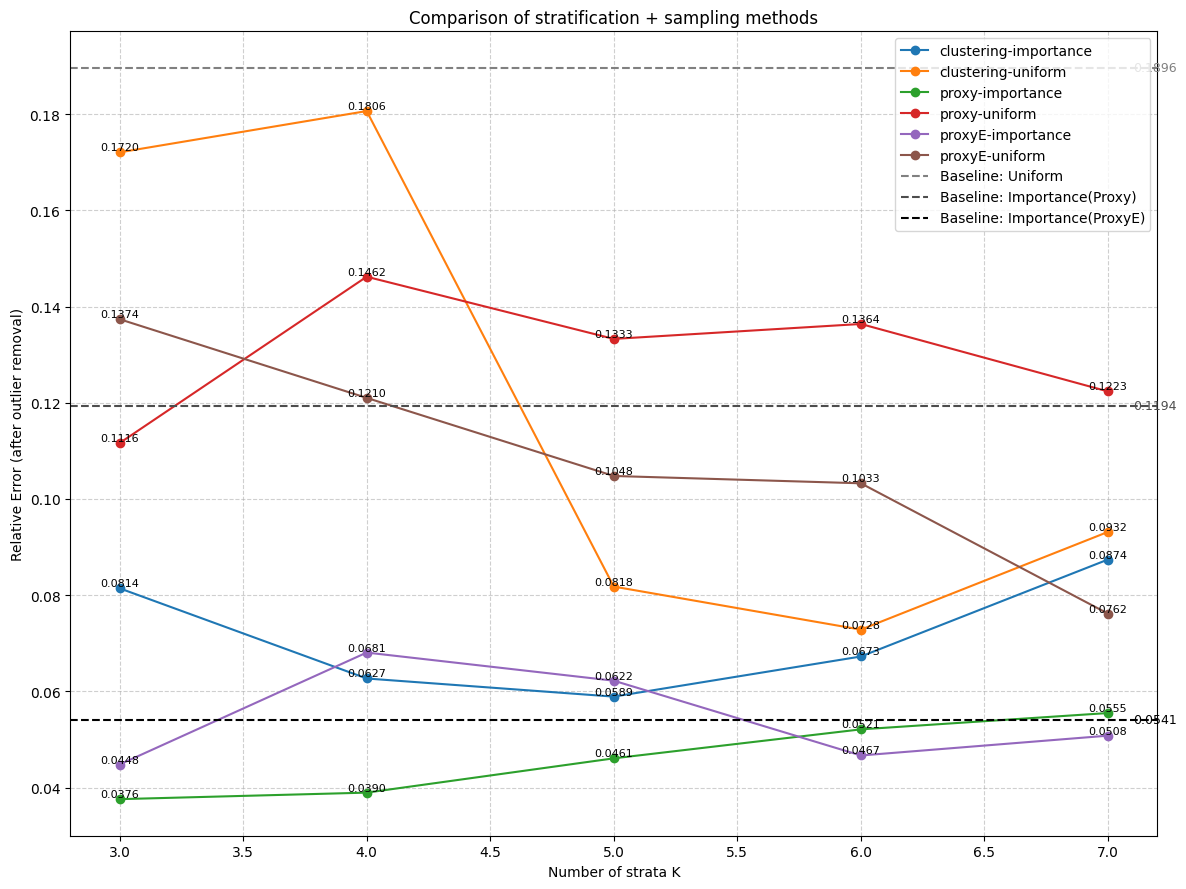

    K        mode    sampling  RelativeError
0   3  clustering  importance       0.081432
1   4  clustering  importance       0.062682
2   5  clustering  importance       0.058914
3   6  clustering  importance       0.067255
4   7  clustering  importance       0.087411
5   3  clustering     uniform       0.172046
6   4  clustering     uniform       0.180628
7   5  clustering     uniform       0.081789
8   6  clustering     uniform       0.072841
9   7  clustering     uniform       0.093152
10  3       proxy  importance       0.037601
11  4       proxy  importance       0.038959
12  5       proxy  importance       0.046085
13  6       proxy  importance       0.052109
14  7       proxy  importance       0.055504
15  3       proxy     uniform       0.111615
16  4       proxy     uniform       0.146195
17  5       proxy     uniform       0.133266
18  6       proxy     uniform       0.136373
19  7       proxy     uniform       0.122347
20  3      proxyE  importance       0.044804
21  4     

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def remove_outliers_and_plot(df: pd.DataFrame):
    cleaned = []
    # ---- 针对每条折线 (mode+sampling) 单独做 IQR ----
    for (mode, sampling), group in df.groupby(["mode", "sampling"]):
        Q1 = group["RelativeError"].quantile(0.25)
        Q3 = group["RelativeError"].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 4.5 * IQR
        upper = Q3 + 4.5 * IQR
        filtered = group[(group["RelativeError"] >= lower) & (group["RelativeError"] <= upper)]
        cleaned.append(filtered)

    df_clean = pd.concat(cleaned, ignore_index=True)

    # ---- 重新绘制折线图 ----
    plt.figure(figsize=(12,9))
    for (mode, sampling), group in df_clean.groupby(["mode", "sampling"]):
        label = f"{mode}-{sampling}"
        plt.plot(group["K"], group["RelativeError"], marker="o", label=label)
        for x, y in zip(group["K"], group["RelativeError"]):
            plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=8)
    # 三条基线横线（你给的数值）
    # baseline_vals = [0.2205, 0.1405, 0.0643]
    baseline_vals = [0.1896, 0.1194, 0.0541]
    baseline_labels = ["Baseline: Uniform", "Baseline: Importance(Proxy)", "Baseline: Importance(ProxyE)"]
    baseline_colors = [ (0.5, 0.5, 0.5),  (0.3, 0.3, 0.3), (0.0, 0.0, 0.0) ]
    for val, label, color in zip(baseline_vals, baseline_labels, baseline_colors):
        plt.axhline(y=val, color=color, linestyle="--", linewidth=1.5, label=label)
        plt.text(max(df["K"]) + 0.1, val, f"{val:.4f}",
                 va="center", ha="left", fontsize=9, color=color)

    plt.xlabel("Number of strata K")
    plt.ylabel("Relative Error (after outlier removal)")
    plt.title("Comparison of stratification + sampling methods")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return df_clean
df_clean = remove_outliers_and_plot(df_res)
print(df_clean)